# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 24 - 2do bimestre 2026

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [79]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [46]:
pd.set_option("display.max_columns",None)

In [68]:
#Importamos set de entrenamiento
path = r'.\adult_train.csv'
df = pd.read_csv(path)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30162 entries, 0 to 30161
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  str  
 2   education       30162 non-null  str  
 3   marital-status  30162 non-null  str  
 4   occupation      30162 non-null  str  
 5   relationship    30162 non-null  str  
 6   race            30162 non-null  str  
 7   sex             30162 non-null  str  
 8   capital-gain    30162 non-null  int64
 9   capital-loss    30162 non-null  int64
 10  hours-per-week  30162 non-null  int64
 11  skill-profile   30162 non-null  str  
 12  native-country  30162 non-null  str  
 13  income          30162 non-null  str  
dtypes: int64(4), str(10)
memory usage: 3.2 MB


Vemos que no tenemos valores nulos (NaN) en ninguna columna

<h2><b>Revisión de cardinalidad de las columnas categóricas

In [18]:
#verificación de valores únicos en variables categoricas
categorial_columns = df.select_dtypes(include=['object','str']).columns
numerical_columns = df.select_dtypes(include=[np.number]).columns

for column in categorial_columns:
    print(f"Tenemos {len((df[column].unique()))}    valores únicos en la columna    {column}")

Tenemos 7    valores únicos en la columna    workclass
Tenemos 16    valores únicos en la columna    education
Tenemos 7    valores únicos en la columna    marital-status
Tenemos 14    valores únicos en la columna    occupation
Tenemos 6    valores únicos en la columna    relationship
Tenemos 5    valores únicos en la columna    race
Tenemos 2    valores únicos en la columna    sex
Tenemos 80    valores únicos en la columna    skill-profile
Tenemos 41    valores únicos en la columna    native-country
Tenemos 2    valores únicos en la columna    income


<p>Observamos que las siguientes columnas serán consideradas de alta cardinalidad: 
    <ul>
        <li>education</li>
        <li>occupation</li>
        <li>skill-profile</li>
        <li>native-country</li>
    </ul>
</p>

<h2>Distribución del target

Como primer paso, revisaremos si el dataset se encuentra balanceado, respecto de nuestra variable target

<Axes: >

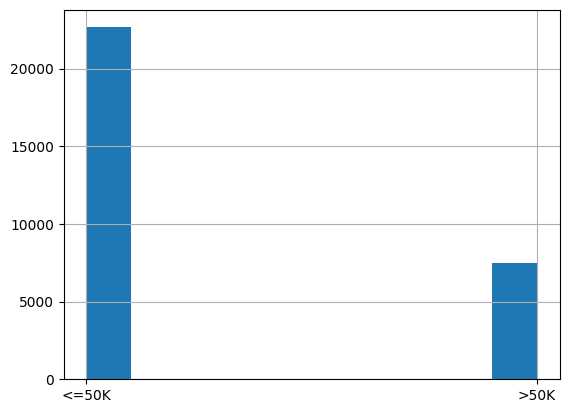

In [70]:
df["income"].hist()

Vemos que el dataset está claramente no balanceado, siendo que la mayoría de las muestras corresponden a la categoría "<=50K". <b>Se deberá tener un consideración al armar los dataset de validación y entrenamiento

Revisaremos los mismo, para ver la distribución del resto de nuestros features: 

In [108]:
#defino tamaño del gráfico
columnas = 5
filas = math.ceil(len(categorial_columns)/columnas)

#instacio figura


colum_index = 0
row_index = 0
for idx,column in enumerate(categorial_columns):

    plt.subplot(len(categorial_columns),2,idx)   # (rows, columns, panel number)
    sns.histplot(
        df,
        x=column,
        
    )

    #avanzo el índice de columna
    if colum_index < columnas:
        colum_index+=1
    #verifico si llegué al final de la fila
    if colum_index>=columnas and row_index<filas:
        colum_index=0
        row_index+=1

    #si recorrí todas las filas, salgo del loop    
    if row_index>=filas:
        break

plt.tight_layout()
plt.show()


ValueError: num must be an integer with 1 <= num <= 20, not 0

<Figure size 640x480 with 0 Axes>

<h2>Variable <b>workclass</b></h2>

In [28]:
#revisamos los valores unicos de workclass
df["workclass"].unique()

<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',     'Self-emp-inc',
      'Without-pay']
Length: 7, dtype: str

<p><b>"Workclass"</b> es una variable categórica de siete valores únicos, en los que no podemos detectar un orden específico entre las categorías, por lo cuál, se opta por realizar un tipo de codificación "One-Hot-Encoding"

In [ ]:
#OHE para columna "workclass"
encoded_workclass = pd.get_dummies(df["workclass"]).astype(int) #generación de la codificación one hot
encoded_workclass.drop(columns="Without-pay",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_workclass],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="workclass",inplace=True)                       #drop columna original 
df.head(10)

,age,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Federal-gov,Local-gov,Private,Self-emp-inc,Self-emp-not-inc,State-gov
0,39,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,0,0,1
1,50,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,0,1,0
2,38,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,United-States,<=50K,0,0,1,0,0,0
3,53,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,0,0
4,28,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0,0
5,37,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,personal_care_assistance,United-States,<=50K,0,0,1,0,0,0
6,49,9th,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K,0,0,1,0,0,0
7,52,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,transport_commercial_driving,United-States,>50K,0,0,0,0,1,0
8,31,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,tech_software_engineering,United-States,>50K,0,0,1,0,0,0
9,42,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,consulting_process_improvement,United-States,>50K,0,0,1,0,0,0


<h2>Variable <b>marital-status</b></h2>

In [40]:
df["marital-status"].unique()

<StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

<p>Al igual que sucede con la columna workclass, vemos que las codificación más adecuada en la One-Hot</p>

In [42]:
#OHE para columna "marital-status"
encoded_marital_status = pd.get_dummies(df["marital-status"]).astype(int) #generación de la codificación one hot
encoded_marital_status.drop(columns="Widowed",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_marital_status],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="marital-status",inplace=True)                       #drop columna original 
df.head(10)

,age,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,skill-profile,...,Private,Self-emp-inc,Self-emp-not-inc,State-gov,Divorced,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated
0,39,Bachelors,Adm-clerical,Not-in-family,White,Male,2174,0,40,manufacturing_assembly,...,0,0,0,1,0,0,0,0,1,0
1,50,Bachelors,Exec-managerial,Husband,White,Male,0,0,13,accounting_bookkeeping,...,0,0,1,0,0,0,1,0,0,0
2,38,HS-grad,Handlers-cleaners,Not-in-family,White,Male,0,0,40,agriculture_field_work,...,1,0,0,0,1,0,0,0,0,0
3,53,11th,Handlers-cleaners,Husband,Black,Male,0,0,40,office_data_entry_basic,...,1,0,0,0,0,0,1,0,0,0
4,28,Bachelors,Prof-specialty,Wife,Black,Female,0,0,40,tech_programming_advanced,...,1,0,0,0,0,0,1,0,0,0
5,37,Masters,Exec-managerial,Wife,White,Female,0,0,40,personal_care_assistance,...,1,0,0,0,0,0,1,0,0,0
6,49,9th,Other-service,Not-in-family,Black,Female,0,0,16,food_service_kitchen_basic,...,1,0,0,0,0,0,0,1,0,0
7,52,HS-grad,Exec-managerial,Husband,White,Male,0,0,45,transport_commercial_driving,...,0,0,1,0,0,0,1,0,0,0
8,31,Masters,Prof-specialty,Not-in-family,White,Female,14084,0,50,tech_software_engineering,...,1,0,0,0,0,0,0,0,1,0
9,42,Bachelors,Exec-managerial,Husband,White,Male,5178,0,40,consulting_process_improvement,...,1,0,0,0,0,0,1,0,0,0


<h2>Variable <b>relationship</b></h2>

In [48]:
df["relationship"].unique()

<StringArray>
['Not-in-family', 'Husband', 'Wife', 'Own-child', 'Unmarried',
 'Other-relative']
Length: 6, dtype: str

In [58]:
df.groupby(by=["marital-status"],as_index=False)["relationship"].unique()

,marital-status,relationship
0,Divorced,"[Not-in-family, Unmarried, Own-child, Other-re..."
1,Married-AF-spouse,"[Wife, Husband, Own-child, Other-relative]"
2,Married-civ-spouse,"[Husband, Wife, Own-child, Other-relative, Not..."
3,Married-spouse-absent,"[Not-in-family, Unmarried, Own-child, Other-re..."
4,Never-married,"[Not-in-family, Own-child, Unmarried, Other-re..."
5,Separated,"[Unmarried, Own-child, Other-relative, Not-in-..."
6,Widowed,"[Unmarried, Not-in-family, Own-child, Other-re..."


¿Existe una correlación entre esta variable "relationship" y la variable "martial-status? ¿Son ambas necesarias? ¿Cómo saberlo ? 

<h2>Variable <b>race</b></h2>

In [59]:
df["race"].unique()

<StringArray>
['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
Length: 5, dtype: str

In [61]:
#OHE para columna "race"
encoded_race = pd.get_dummies(df["race"]).astype(int) #generación de la codificación one hot
encoded_race.drop(columns="Other",inplace=True)      #drop de una de las columnas codificadas
df = pd.concat([df,encoded_race],axis=1)                   #axis: 1 = columna | 0 = fila
df.drop(columns="race",inplace=True)                       #drop columna original 
df.head(10)

,age,workclass,education,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,1
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,1
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40,agriculture_field_work,United-States,<=50K,0,0,0,1
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0
5,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,Female,0,0,40,personal_care_assistance,United-States,<=50K,0,0,0,1
6,49,Private,9th,Married-spouse-absent,Other-service,Not-in-family,Female,0,0,16,food_service_kitchen_basic,Jamaica,<=50K,0,0,1,0
7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,45,transport_commercial_driving,United-States,>50K,0,0,0,1
8,31,Private,Masters,Never-married,Prof-specialty,Not-in-family,Female,14084,0,50,tech_software_engineering,United-States,>50K,0,0,0,1
9,42,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Male,5178,0,40,consulting_process_improvement,United-States,>50K,0,0,0,1


<h2>Variable <b>sex</b></h2>

In [63]:
df["sex"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

En este caso con una sola columa, podemos codificarlo: 

In [65]:
df["sex"]=="Male"

0         True
1         True
2         True
3         True
4        False
         ...  
30157    False
30158     True
30159    False
30160     True
30161    False
Name: sex, Length: 30162, dtype: bool

In [67]:
df["male"] = df["sex"]=="Male"
df["male"] = df["male"].astype(int)
df.drop(columns="sex",inplace=True)
df

,age,workclass,education,marital-status,occupation,relationship,capital-gain,capital-loss,hours-per-week,skill-profile,native-country,income,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,White,male
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,2174,0,40,manufacturing_assembly,United-States,<=50K,0,0,0,1,1
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,0,0,13,accounting_bookkeeping,United-States,<=50K,0,0,0,1,1
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,0,0,40,agriculture_field_work,United-States,<=50K,0,0,0,1,1
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,0,0,40,office_data_entry_basic,United-States,<=50K,0,0,1,0,1
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,0,0,40,tech_programming_advanced,Cuba,<=50K,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,0,0,38,tech_programming_basic,United-States,<=50K,0,0,0,1,0
30158,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,0,0,40,trade_welding,United-States,>50K,0,0,0,1,1
30159,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,0,0,40,trade_electrical,United-States,<=50K,0,0,0,1,0
30160,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,0,0,20,tech_computer_literacy,United-States,<=50K,0,0,0,1,1


<h2>Variables <b>education</b>, <b>occupation</b>, <b>skill-profile</b> y <b>native-country</b></h2>

<p>Para estas variables, dado su valor de cardinalidad (especificado al inicio de este análisis) se procederá a realizar una codificación mediante Embeddings

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.